# Informe Exploratorio de Datos (EDA) y Evaluación de Reglas de Negocio
**Caso de Uso: Pontia Logista - Visión Artificial y Gestión de Distribución**

Este cuaderno de Jupyter contiene el **Análisis Exploratorio de Datos (EDA)** con gráficos interactivos y tabulaciones para la evaluación de las reglas de negocio de **Pontia Logista**, según la especificación del proyecto.

---

## 1. Carga de Librerías y Preparación de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética de los gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Cargar tablas relacionales
clientes = pd.read_csv('../../contenidos/DataFrames/db_cliente.csv')
lotes = pd.read_csv('../../contenidos/DataFrames/db_lote.csv')
marcas = pd.read_csv('../../contenidos/DataFrames/db_marca.csv')
productos = pd.read_csv('../../contenidos/DataFrames/db_producto.csv', low_memory=False)
proveedores = pd.read_csv('../../contenidos/DataFrames/db_proveedores.csv')
subtipos = pd.read_csv('../../contenidos/DataFrames/db_subtipo.csv')
tipos = pd.read_csv('../../contenidos/DataFrames/db_tipo.csv')
ventas = pd.read_csv('../../contenidos/DataFrames/db_venta.csv', low_memory=False)


# Conversión de variables temporales
productos['tiempo_recogida_dt'] = pd.to_datetime(productos['tiempo_recogida'])
ventas['tiempo_venta_dt'] = pd.to_datetime(ventas['tiempo_venta'])

# Dataset consolidado de operaciones
df = pd.merge(ventas, productos, left_on='id_producto', right_on='id', suffixes=('_venta', '_producto'))
df['fecha_recogida'] = df['tiempo_recogida_dt'].dt.date
df['fecha_venta_only'] = df['tiempo_venta_dt'].dt.date

print('Todo OK')

Todo OK


## 2. Evaluación de Reglas de Negocio

### 2.1 Regla 1: Como mínimo transcurre un día diferente entre la recogida y la venta al cliente
*Criterio:* La fecha de venta (`fecha_venta`) debe ser posterior (día calendario distinto) a la fecha de recogida (`fecha_recogida`).

,Condición de Fecha,Cantidad de Transacciones,Porcentaje (%)
0,Mismo día (No cumple),50260,71.24
1,Día posterior (Cumple regla),19170,27.17
2,Día anterior (Incoherencia/Error),894,1.27
3,Fecha Venta Nula,225,0.32


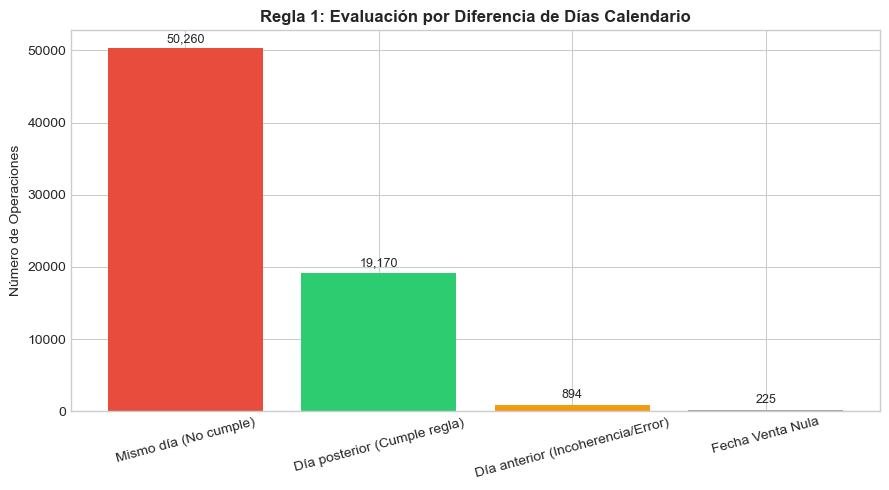

In [9]:
# Clasificación según días de diferencia
mismo_dia = (df['fecha_venta_only'] == df['fecha_recogida']).sum()
dia_posterior = (df['fecha_venta_only'] > df['fecha_recogida']).sum()
dia_anterior = (df['fecha_venta_only'] < df['fecha_recogida']).sum()
sin_fecha = df['fecha_venta_only'].isnull().sum()

regla1_df = pd.DataFrame({
    'Condición de Fecha': ['Mismo día (No cumple)', 'Día posterior (Cumple regla)', 'Día anterior (Incoherencia/Error)', 'Fecha Venta Nula'],
    'Cantidad de Transacciones': [mismo_dia, dia_posterior, dia_anterior, sin_fecha],
    'Porcentaje (%)': [round(x/len(df)*100, 2) for x in [mismo_dia, dia_posterior, dia_anterior, sin_fecha]]
})

display(regla1_df)

# Gráfico de barras de la Regla 1
plt.figure(figsize=(9, 5))
bars = plt.bar(regla1_df['Condición de Fecha'], regla1_df['Cantidad de Transacciones'], color=['#e74c3c', '#2ecc71', '#f39c12', '#95a5a6'])
plt.title('Regla 1: Evaluación por Diferencia de Días Calendario', fontsize=12, fontweight='bold')
plt.ylabel('Número de Operaciones')
plt.xticks(rotation=15)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, f'{yval:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 2.2 Regla 2: Máximo 100 kg por Proveedor y Tipo de Fruta en un Mismo Día

Agrupaciones que exceden el límite de 100 kg/día: 0


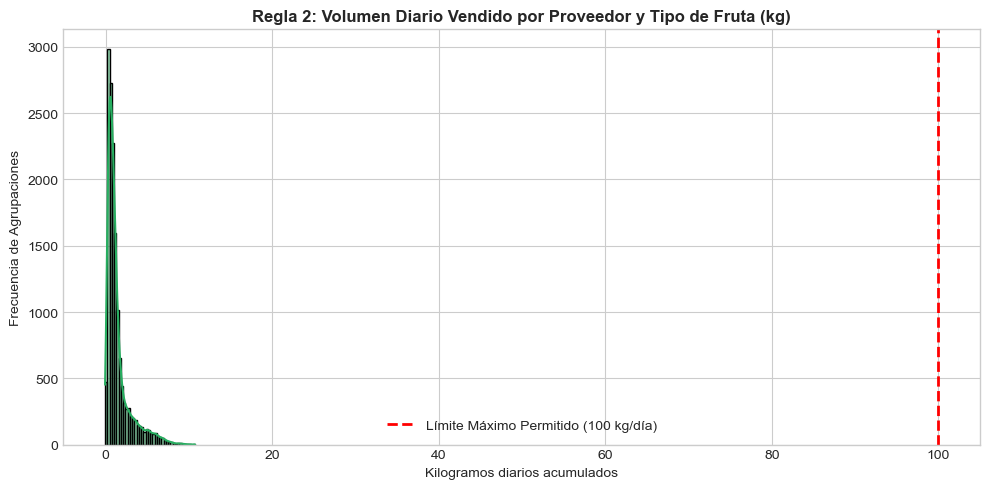

In [10]:
# Agrupar por proveedor, fecha de venta y tipo de fruta
prov_dia = df.groupby(['id_proveedor', 'fecha_venta_only', 'id_tipo'])['peso'].sum().reset_index()
prov_dia['peso_kg'] = prov_dia['peso'] / 1000.0  # Gramos a Kilogramos

excesos = prov_dia[prov_dia['peso_kg'] > 100.0]
print(f'Agrupaciones que exceden el límite de 100 kg/día: {len(excesos)}')

# Gráfico de distribución de pesos diarios por proveedor
plt.figure(figsize=(10, 5))
sns.histplot(prov_dia['peso_kg'], bins=40, color='#27ae60', kde=True)
plt.axvline(100, color='red', linestyle='--', linewidth=2, label='Límite Máximo Permitido (100 kg/día)')
plt.title('Regla 2: Volumen Diario Vendido por Proveedor y Tipo de Fruta (kg)', fontsize=12, fontweight='bold')
plt.xlabel('Kilogramos diarios acumulados')
plt.ylabel('Frecuencia de Agrupaciones')
plt.legend()
plt.tight_layout()
plt.show()

### 2.3 Regla 3: Unicidad de Tipo de Fruta por Marca

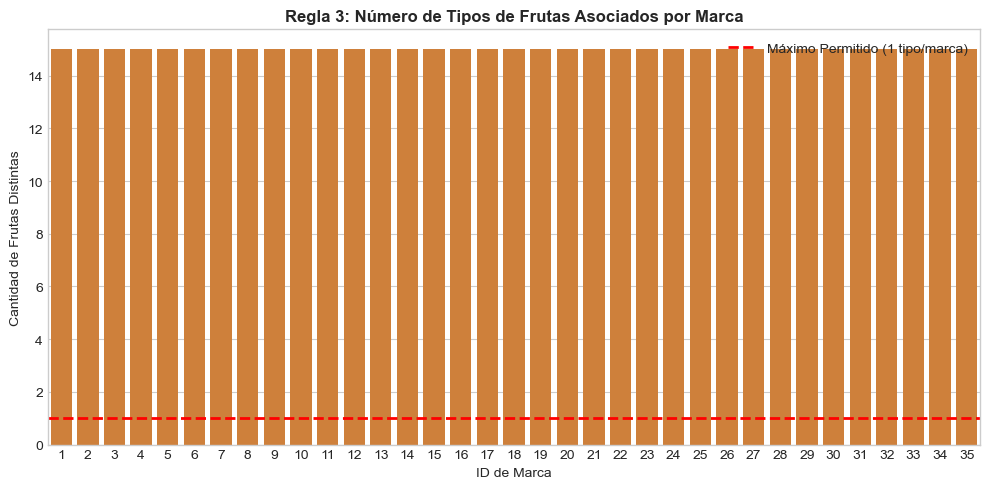

Resumen de marcas con más de un tipo de fruta:


,id_marca,cantidad_tipos_fruta
0,1,15
1,2,15
2,3,15
3,4,15
4,5,15
5,6,15
6,7,15
7,8,15
8,9,15
9,10,15


In [4]:
# Variedad de frutas producidas por cada marca
marcas_frutas = productos.groupby('id_marca')['id_tipo'].nunique().reset_index()
marcas_frutas.columns = ['id_marca', 'cantidad_tipos_fruta']

plt.figure(figsize=(10, 5))
sns.barplot(data=marcas_frutas, x='id_marca', y='cantidad_tipos_fruta', color='#e67e22')
plt.axhline(1, color='red', linestyle='--', linewidth=2, label='Máximo Permitido (1 tipo/marca)')
plt.title('Regla 3: Número de Tipos de Frutas Asociados por Marca', fontsize=12, fontweight='bold')
plt.xlabel('ID de Marca')
plt.ylabel('Cantidad de Frutas Distintas')
plt.legend()
plt.tight_layout()
plt.show()

print('Resumen de marcas con más de un tipo de fruta:')
display(marcas_frutas.head(10))

### 2.4 Regla 4: Homogeneidad del Lote (Marcas y Frutas Únicas por Lote)

,Lotes Homogéneos (Correctos),Lotes Inconsistentes (Mezclados)
Mezcla de Tipos de Fruta,69055,512
Mezcla de Marcas,69452,115


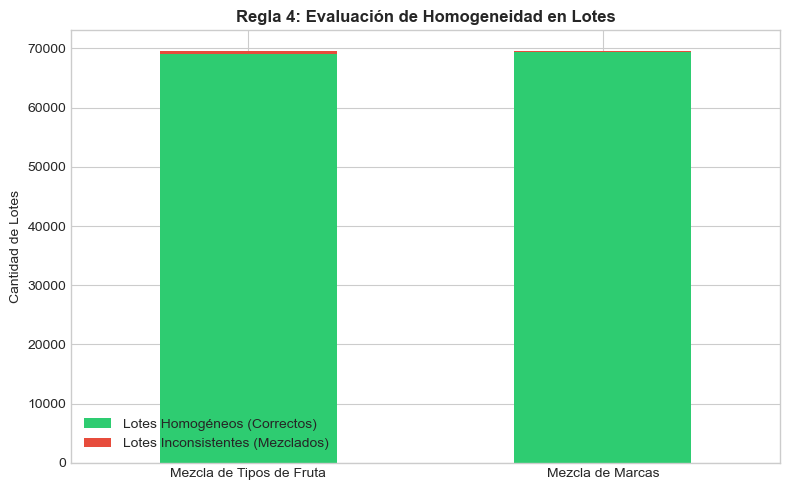

In [5]:
# Conteo de frutas y marcas distintas por lote
lote_tipos = productos.groupby('id_lote')['id_tipo'].nunique()
lote_marcas = productos.groupby('id_lote')['id_marca'].nunique()

lote_summary = pd.DataFrame({
    'Lotes Homogéneos (Correctos)': [(lote_tipos == 1).sum(), (lote_marcas == 1).sum()],
    'Lotes Inconsistentes (Mezclados)': [(lote_tipos > 1).sum(), (lote_marcas > 1).sum()]
}, index=['Mezcla de Tipos de Fruta', 'Mezcla de Marcas'])

display(lote_summary)

# Gráfico acumulado de homogeineidad en lotes
lote_summary.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(8, 5))
plt.title('Regla 4: Evaluación de Homogeneidad en Lotes', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Lotes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Detección de Valores Nulos / Faltantes


In [2]:
# Resumen global de valores nulos por tabla
tablas = {
    'db_cliente': clientes,
    'db_lote': lotes,
    'db_marca': marcas,
    'db_producto': productos,
    'db_proveedores': proveedores,
    'db_subtipo': subtipos,
    'db_tipo': tipos,
    'db_venta': ventas
}

nulos_resumen = []
for nombre, df in tablas.items():
    nulos = df.isnull().sum()
    for col, count in nulos.items():
        if count > 0:
            nulos_resumen.append({
                'Tabla': nombre,
                'Columna': col,
                'Valores Nulos': count,
                'Porcentaje (%)': round((count / len(df)) * 100, 2)
            })

df_nulos = pd.DataFrame(nulos_resumen)
print('=== RESUMEN DE VALORES NULOS ===')
display(df_nulos)

=== RESUMEN DE VALORES NULOS ===


,Tabla,Columna,Valores Nulos,Porcentaje (%)
0,db_producto,coste_inicial,2011,2.85
1,db_producto,subtipo,31201,44.23
2,db_producto,id_subtipo,31201,44.23
3,db_venta,precio_venta,694,0.98
4,db_venta,tiempo_venta,225,0.32
5,db_venta,tiempo_venta_dt,225,0.32


## 4. Detección de Incoherencias Lógicas y Físicas

### 4.1 Pesos Negativos o Cero en Ventas

In [3]:
# Filtrar ventas con peso <= 0
ventas_peso_invalido = ventas[ventas['peso'] <= 0]
print(f'Total de registros con peso <= 0: {len(ventas_peso_invalido)}')
print('\nMuestra de datos con peso inválido:')
display(ventas_peso_invalido[['id', 'id_producto', 'peso', 'precio_venta']].head(10))

Total de registros con peso <= 0: 114

Muestra de datos con peso inválido:


,id,id_producto,peso,precio_venta
2193,2194,2194,-19.651172,4.417843
2281,2282,2282,-23.473025,3.968082
3185,3186,3186,-25.641255,2.358227
4236,4237,4237,-6.082857,4.016483
5711,5712,5712,-66.097484,3.593772
5840,5841,5841,-9.393216,2.530311
5864,5865,5865,-67.222202,2.872869
6516,6517,6517,-14.807528,3.885866
6521,6522,6522,-11.245793,3.748054
6818,6819,6819,-37.387748,3.894348


### 4.2 Fecha de Venta Anterior a Fecha de Recogida

In [4]:
# Convertir columnas a datetime
productos['tiempo_recogida_dt'] = pd.to_datetime(productos['tiempo_recogida'])
ventas['tiempo_venta_dt'] = pd.to_datetime(ventas['tiempo_venta'])

# Unir ventas con productos para comparar fechas
df_merge_fechas = pd.merge(ventas, productos, left_on='id_producto', right_on='id', suffixes=('_venta', '_producto'))

# Filtrar incongruencia temporal
fechas_incoherentes = df_merge_fechas[df_merge_fechas['tiempo_venta_dt'] < df_merge_fechas['tiempo_recogida_dt']]
print(f'Total de transacciones con fecha de venta anterior a recogida: {len(fechas_incoherentes)}')
print('\nMuestra de incoherencias temporales:')
display(fechas_incoherentes[['id_venta', 'id_producto', 'tiempo_recogida', 'tiempo_venta']].head(10))

Total de transacciones con fecha de venta anterior a recogida: 1160

Muestra de incoherencias temporales:


,id_venta,id_producto,id_producto,tiempo_recogida,tiempo_venta
51,52,52,52,2025-09-04 23:00:00,2025-09-01 00:00:00
87,88,88,88,2025-09-07 18:00:00,2025-09-01 06:00:00
230,231,231,231,2025-09-08 19:00:00,2025-09-01 03:00:00
246,247,247,247,2025-09-16 20:00:00,2025-09-16 19:00:00
364,365,365,365,2025-09-11 13:00:00,2025-08-31 20:00:00
365,366,366,366,2025-09-26 23:00:00,2025-08-31 22:00:00
392,393,393,393,2025-09-09 05:00:00,2025-08-31 23:00:00
448,449,449,449,2025-09-23 06:00:00,2025-09-23 02:00:00
681,682,682,682,2025-09-01 22:00:00,2025-09-01 06:00:00
724,725,725,725,2025-09-14 04:00:00,2025-09-01 06:00:00


## 5. Duplicados 

### 5.1 Flag `repetido = 1` y Duplicados en Imagen/Código (`t_id`)

In [5]:
# Registros con repetido == 1
repetidos = productos[productos['repetido'] == 1]
print(f'Total de productos marcados con repetido = 1: {len(repetidos)}')

# Identificadores t_id duplicados en el catálogo
t_id_duplicados = productos[productos['t_id'].duplicated(keep=False)]
print(f'Total de filas involucradas en duplicidad de t_id: {len(t_id_duplicados)}')
print('\nMuestra de t_id duplicados:')
display(t_id_duplicados[['id', 't_id', 'imagen', 'id_tipo', 'coste_inicial']].sort_values('t_id').head(10))

Total de productos marcados con repetido = 1: 1459
Total de filas involucradas en duplicidad de t_id: 1459

Muestra de t_id duplicados:


,id,t_id,imagen,id_tipo,coste_inicial
1905,1906,scene00001.png,/contenidos/archive/Apple/Apple C/scene00001.png,1,2.475298
5865,5866,scene00001.png,/contenidos/archive/Apple/Apple F/scene00001.png,1,2.475298
17139,17140,scene00001.png,/contenidos/archive/Guava/guava A/scene00001.png,4,2.475298
5866,5867,scene00041.png,/contenidos/archive/Apple/Apple F/scene00041.png,1,2.025128
17141,17142,scene00041.png,/contenidos/archive/Guava/guava A/scene00041.png,4,2.025128
1906,1907,scene00081.png,/contenidos/archive/Apple/Apple C/scene00081.png,1,1.559304
17142,17143,scene00081.png,/contenidos/archive/Guava/guava A/scene00081.png,4,1.559304
5867,5868,scene00081.png,/contenidos/archive/Apple/Apple F/scene00081.png,1,1.559304
5868,5869,scene00101.png,/contenidos/archive/Apple/Apple F/scene00101.png,1,0.760675
17143,17144,scene00101.png,/contenidos/archive/Guava/guava A/scene00101.png,4,0.760675


### 5.2 Reutilización Indebida de Lotes (`id_lote`)

In [6]:
# Conteo de ocurrencias de cada lote en db_producto
lotes_counts = productos['id_lote'].value_counts()
lotes_compartidos = lotes_counts[lotes_counts > 1]

print(f'Total de id_lote asignados a múltiples productos: {len(lotes_compartidos)}')
print('\nTop 10 lotes con mayor número de productos asociados:')
display(lotes_compartidos.head(10))

Total de id_lote asignados a múltiples productos: 717

Top 10 lotes con mayor número de productos asociados:


id_lote
1310    5
1315    5
1292    5
1297    5
1280    5
1231    5
1277    5
1235    5
1245    5
1283    5
Name: count, dtype: int64

## 6. Resumen de Errores

In [9]:
resumen_general = [
    {'Categoría': 'Valores Nulos', 'Métrica': 'subtipo / id_subtipo faltantes', 'Cantidad': int(productos['subtipo'].isnull().sum())},
    {'Categoría': 'Valores Nulos', 'Métrica': 'coste_inicial faltante', 'Cantidad': int(productos['coste_inicial'].isnull().sum())},
    {'Categoría': 'Valores Nulos', 'Métrica': 'precio_venta faltante', 'Cantidad': int(ventas['precio_venta'].isnull().sum())},
    {'Categoría': 'Valores Nulos', 'Métrica': 'tiempo_venta faltante', 'Cantidad': int(ventas['tiempo_venta'].isnull().sum())},
    {'Categoría': 'Incoherencia Lógica', 'Métrica': 'Peso negativo o cero (<= 0 g)', 'Cantidad': int((ventas['peso'] <= 0).sum())},
    {'Categoría': 'Incoherencia Temporal', 'Métrica': 'Venta previa a recogida (tiempo_venta < tiempo_recogida)', 'Cantidad': int(len(fechas_incoherentes))},
    #{'Categoría': 'Discrepancia Texto', 'Métrica': 'Subtipo en producto != Dimensión db_subtipo', 'Cantidad': int(len(subtipo_mismatch))},
    #{'Categoría': 'Discrepancia Texto', 'Métrica': 'Cliente en venta != Dimensión db_cliente', 'Cantidad': int(len(cliente_mismatch))},
    {'Categoría': 'Duplicidad', 'Métrica': 'Flag repetido = 1 en db_producto', 'Cantidad': int((productos['repetido'] == 1).sum())},
    {'Categoría': 'Duplicidad', 'Métrica': 'Identificadores t_id duplicados', 'Cantidad': int(productos['t_id'].duplicated().sum())},
    {'Categoría': 'Anomalía Relacional', 'Métrica': 'Lotes compartidos por >1 producto', 'Cantidad': int(len(lotes_compartidos))}
]

df_resumen_final = pd.DataFrame(resumen_general)
display(df_resumen_final)

,Categoría,Métrica,Cantidad
0,Valores Nulos,subtipo / id_subtipo faltantes,31201
1,Valores Nulos,coste_inicial faltante,2011
2,Valores Nulos,precio_venta faltante,694
3,Valores Nulos,tiempo_venta faltante,225
4,Incoherencia Lógica,Peso negativo o cero (<= 0 g),114
5,Incoherencia Temporal,Venta previa a recogida (tiempo_venta < tiempo...,1160
6,Duplicidad,Flag repetido = 1 en db_producto,1459
7,Duplicidad,Identificadores t_id duplicados,862
8,Anomalía Relacional,Lotes compartidos por >1 producto,717
